Doctor Visit Analysis Project


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
data = pd.read_csv(fn)

Saving DoctorVisits-DA.csv to DoctorVisits-DA (2).csv
User uploaded file "DoctorVisits-DA (2).csv" with length 305268 bytes


**1.Number of duplicates in the dataset**

In [ ]:
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


**2.Total number of people based on their count of illness**

In [ ]:
illness_count = data['illness'].value_counts()
print("Illness count:\n", illness_count)

Illness count:
 illness
1    1638
0    1554
2     946
3     542
4     274
5     236
Name: count, dtype: int64


**3.Gender-wise illness**

In [ ]:
gender_illness = data.groupby('gender')['illness'].mean()
print("Gender-wise average illness:\n", gender_illness)

Gender-wise average illness:
 gender
female    1.611029
male      1.237540
Name: illness, dtype: float64


**4.Maximum, Minimum, and Median income**

In [ ]:
max_income = data['income'].max()
min_income = data['income'].min()
median_income = data['income'].median()
print(f"Maximum Income: {max_income}, Minimum Income: {min_income}, Median Income: {median_income}")

Maximum Income: 1.5, Minimum Income: 0.0, Median Income: 0.55


**5.Number of days of reduced activity for Male and Female**

In [ ]:
reduced_activity = data.groupby('gender')['reduced'].mean()
print("Reduced activity days by gender:\n", reduced_activity)

Reduced activity days by gender:
 gender
female    0.975574
male      0.738344
Name: reduced, dtype: float64


**6.Missing values visualization**

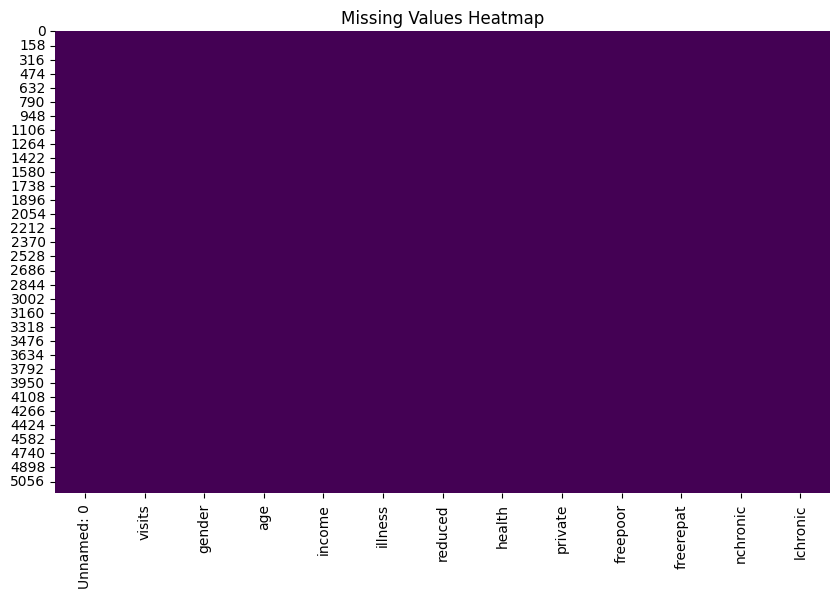

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.savefig('missing_values_heatmap.png')
plt.show()

**7. Correlation between variables**

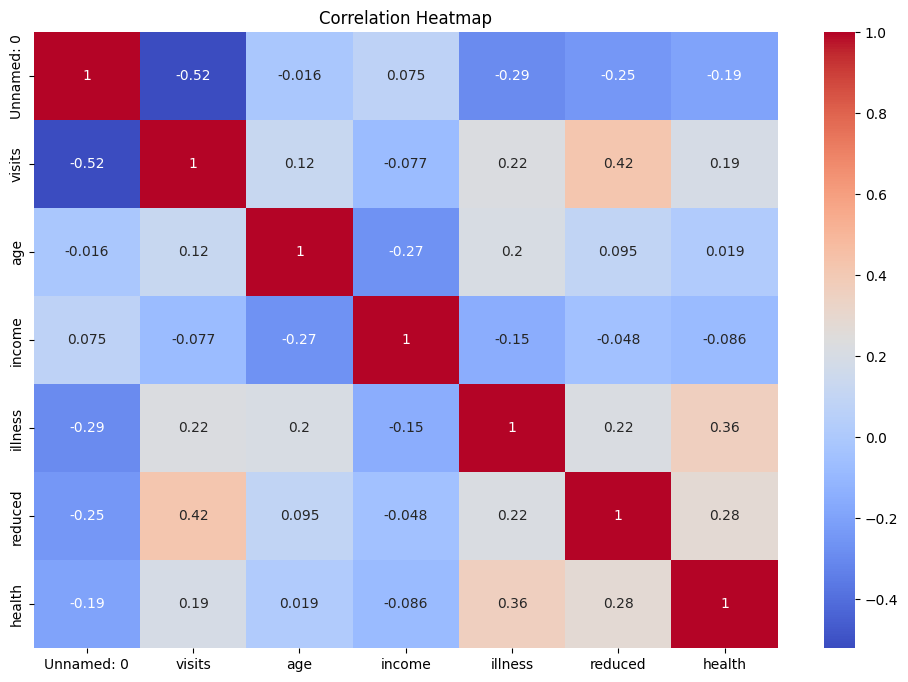

In [ ]:
numeric_data = data.select_dtypes(include=['number'])
plt.figure(figsize=(12, 8))
correlation_matrix = numeric_data.corr()  # Calculate correlation on numeric data only
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

**8.Income vs Hospital Visits**

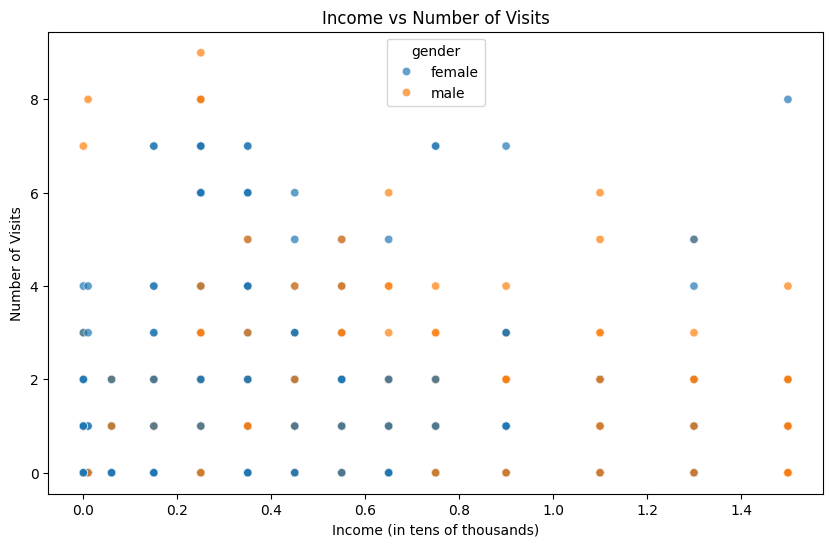

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='income', y='visits', hue='gender', alpha=0.7)
plt.title('Income vs Number of Visits')
plt.xlabel('Income (in tens of thousands)')
plt.ylabel('Number of Visits')
plt.savefig('income_vs_visits.png')
plt.show()


**9.Count of Males and Females affected by illness**

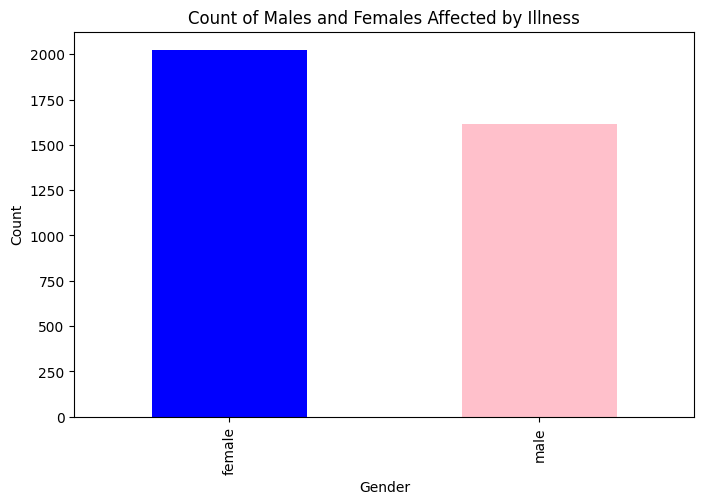

In [ ]:
gender_affected = data[data['illness'] > 0]['gender'].value_counts()
plt.figure(figsize=(8, 5))
gender_affected.plot(kind='bar', color=['blue', 'pink'])
plt.title('Count of Males and Females Affected by Illness')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.savefig('gender_affected.png')
plt.show()

**10.Govt. health insurance percentage**

In [ ]:
private_insurance = data['private'].value_counts(normalize=True).get('Yes', 0) * 100
print("Govt. Health Insurance (Freepoor):\n", govt_health_insurance)
print(f"Percentage of People with Private Insurance: {private_insurance}%")

Govt. Health Insurance (Freepoor):
 freepoor
no     95.722543
yes     4.277457
Name: proportion, dtype: float64
Percentage of People with Private Insurance: 0%


**11. Reduced activity days based on gender**

<ipython-input-29-7e8621743204>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=data, x='gender', y='reduced', ci=None, palette='muted')
<ipython-input-29-7e8621743204>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='gender', y='reduced', ci=None, palette='muted')


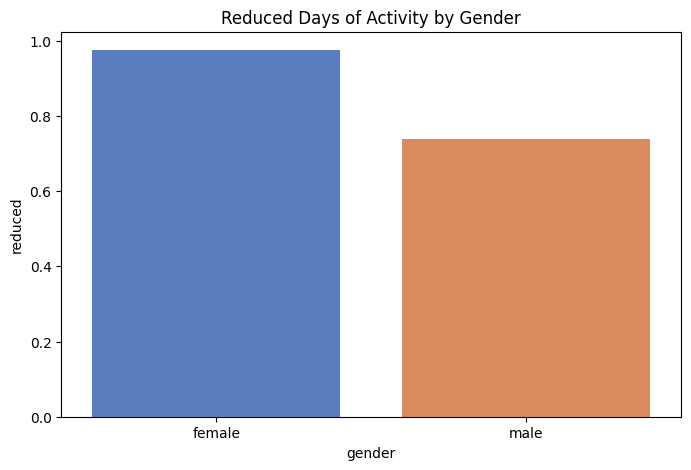

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=data, x='gender', y='reduced', ci=None, palette='muted')
plt.title('Reduced Days of Activity by Gender')
plt.savefig('reduced_days_gender.png')
plt.show()

**12. Health status vs Activity reduction**

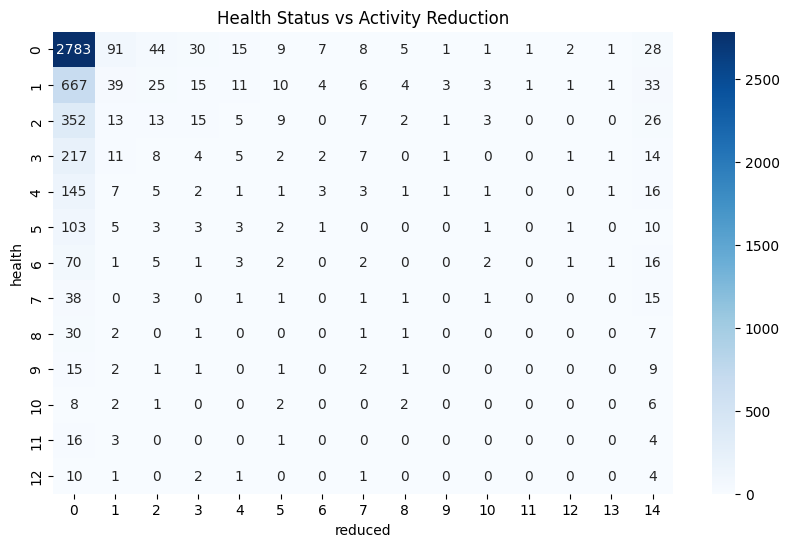

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(data['health'], data['reduced']), cmap='Blues', annot=True, fmt='d')
plt.title('Health Status vs Activity Reduction')
plt.savefig('health_vs_activity_heatmap.png')
plt.show()